In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod


/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/conductance
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/h.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/ICaL.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/ICaT.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod/kadist.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/

In [2]:
from neuron import h, gui

# 加载基础的 NEURON GUI 库
h.load_file("nrngui.hoc")

# 依次打开各个 HOC 文件
h.load_file("n128.hoc")               # 几何文件
h.load_file("axon_sections.hoc")      # 轴突部分
h.load_file("basal_dendrite.hoc")     # 基础树突
h.load_file("apical_dendrite.hoc")    # 顶端树突
h.load_file("apical_trunk.hoc")       # 顶端树干
h.load_file("radiatum.hoc")           # 放射区
h.load_file("init.hoc")               # 初始化设置
h.load_file("addgraph.hoc")           # 添加图形显示

--No graphics will be displayed.


Check neuron_morph
	 Note: diam values less than 0.3um are set to 0.3um!
Diam was changed for: 0  points



1.0

In [3]:
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,
               ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', 
               ylabel = 'Frequency/Hz', label='',ynum_decimals =1, 
               nonscatter=True, s0=10):
    if nonscatter:
        if color:
            ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
        else:
            ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    else:
        if color:
            ax2.scatter(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, 
                        label=label, s=s0)
        else:
            ax2.scatter(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label,
                        s=s0)
        
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if dx:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

0.0746802999053033


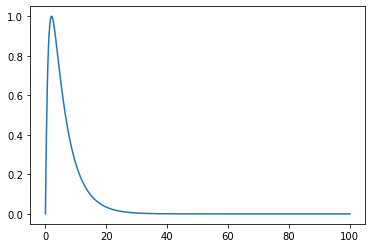

In [4]:
run_dt=0.1
syn_tau1 = 1.
syn_tau2 = 5.
t=np.arange(0,100+run_dt,run_dt)
NE = ((syn_tau1/syn_tau2)**(syn_tau1/(syn_tau2-syn_tau1))-(syn_tau1/syn_tau2)**(syn_tau2/(syn_tau2-syn_tau1)))**-1
uE = NE*(np.exp(-t/syn_tau2)-np.exp(-t/syn_tau1))
plt.plot(t,uE)
ground_truth = np.mean(uE)
print(ground_truth)

In [6]:
len(h.dend)

199

In [7]:
h.topology()


|-|       soma(0-1)
  `--------|       dend[0](0-1)
            `-----------------------|       dend[1](0-1)
            `-|       dend[2](0-1)
               `--|       dend[3](0-1)
                   `--|       dend[4](0-1)
                       `---|       dend[5](0-1)
                       `----|       dend[6](0-1)
                             `-------|       dend[7](0-1)
                             `-------------|       dend[8](0-1)
                   `|       dend[9](0-1)
                     `----|       dend[10](0-1)
                           `----|       dend[11](0-1)
                           `--------|       dend[12](0-1)
                     `--------------|       dend[13](0-1)
               `---|       dend[14](0-1)
                    `-|       dend[15](0-1)
                       `-----|       dend[16](0-1)
                              `------|       dend[17](0-1)
                              `------|       dend[18](0-1)
                                      `--

1.0

# EPSP

In [9]:
def caculatePSP(fE, passive=False, E = True,location='dend', loc=58, plot=True):
    
    h.init()
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("hd", sec=sec):
                # 将电导设置为0
                sec.ghdbar_hd = 0.
            if h.ismembrane("cal", sec=sec):
                sec.gcalbar_cal = 0.
            if h.ismembrane("cat", sec=sec):
                sec.gbar_cat = 0.
            if h.ismembrane("kad", sec=sec):
                sec.gkabar_kad = 0.
            if h.ismembrane("kap", sec=sec):
                sec.gkabar_kap = 0.
            if h.ismembrane("kdr", sec=sec):
                sec.gkdrbar_kdr = 0.
            if h.ismembrane("na3",sec=sec):
                sec.gbar_na3 = 0.
            if h.ismembrane("nax",sec=sec):
                sec.gbar_nax = 0.
    
    if passive:
        h.v_init = -71.3
    else:
        h.v_init = -70.         
    # Set simulation parameters
    h.dt = run_dt
    h.tstop = 600.

    v_clamp = -70.
    
    recv = h.Vector().record(h.soma(0.5)._ref_v)


    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()
    
    syn = h.Exp2Syn(h.dend[int(loc)](0.9))
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -100 for I input
        
    else: 
        syn.e = -100.
        
    stim.number = 1
    stim.start = h.tstop - 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = fE  # uS


    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
        
        go()
        v_array = recv.to_python()
        V_cut = v_array[1000:]
        PSP = np.max(V_cut) - np.min(V_cut)
        # print(v_array[9000])
        if plot:
            plt.plot(v_array)

        return PSP
    
    PSP = main()
    return PSP        

0.9030094045681096


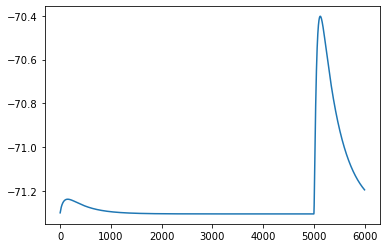

In [10]:
PSP = caculatePSP(6e-4, passive = True, E = True, location='dend', loc=40)
print(PSP)

# recovery of mean local conductance

In [5]:
def recovery_of_local_conductance(run_dt,dV, fE, passive = False, psection=False, E = True, loc=58):


    h.init()
    if passive:
        for sec in h.allsec():
            # 检查 section 是否有主动离子通道
            if h.ismembrane("hd", sec=sec):
                # 将电导设置为0
                sec.ghdbar_hd = 0.
            if h.ismembrane("cal", sec=sec):
                sec.gcalbar_cal = 0.
            if h.ismembrane("cat", sec=sec):
                sec.gbar_cat = 0.
            if h.ismembrane("kad", sec=sec):
                sec.gkabar_kad = 0.
            if h.ismembrane("kap", sec=sec):
                sec.gkabar_kap = 0.
            if h.ismembrane("kdr", sec=sec):
                sec.gkdrbar_kdr = 0.
            if h.ismembrane("na3",sec=sec):
                sec.gbar_na3 = 0.
            if h.ismembrane("nax",sec=sec):
                sec.gbar_nax = 0.
    if psection:
        print(h.soma.psection())   
    if passive:
        h.v_init = -71.3
    else:
        h.v_init = -70.        
    # Set simulation parameters
    h.dt = run_dt
    h.tstop = 600.
    v_clamp = -70.
    
    recv = h.Vector().record(h.soma(0.5)._ref_v)


    # Initialize an excitatory or inhibitory synaptic input
    # make a new stimulator
    stim = h.NetStim()
    
    syn = h.Exp2Syn(h.dend[int(loc)](0.9))
    syn.tau1 = 1.  # ms
    syn.tau2 = 5.  # ms
    if E:
        syn.e = 0.  # mV for E input and -100 for I input
    else: 
        syn.e = -100.
        
    stim.number = 1
    stim.start = h.tstop - 100.  # ms
    ncstim = h.NetCon(stim, syn)
    ncstim.delay = 0.
    ncstim.weight[0] = 0.  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(h.soma(0.5))
    vclamp.amp1 = v_clamp
    vclamp.dur1 = h.tstop
    vclamp.amp2 = v_clamp - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():
    
        Vclamp = np.arange(-100.,-60., dV) 
        Isyn_inj = np.zeros(len(Vclamp))
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstim.weight[0] = 0.
        go()
        recv0 = np.array(recv.to_python())
        V_rest = recv0[-1]
        # print(V_rest)
        Isyn_inj_t = np.zeros((len(Vclamp),1000))

        for i in range(len(Vclamp)):
            ncstim.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            go()
            
            Isyn0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            ncstim.weight[0] = fE
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            go()
            Isyn1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn= - (Isyn1[5001:] - Isyn0[5001:])
            # Isyn_inj[i] = np.sum(Isyn*run_dt)
            Isyn_inj[i] = np.mean(Isyn)
            Isyn_inj_t[i,:] = Isyn
            
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        A1 = Vclamp - V_rest
        x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj, rcond=None)
        mean_local_conductance = - x[1]**2/(x[0]*(syn.e - V_rest)**2)
        A1 = A1 - (syn.e - V_rest)
            
        traditional_effective_conductance = np.zeros(1000)
        for i in range(1000):
            a = np.sum(A1 * Isyn_inj_t[:,i]) / np.sum(A1**2)  # 计算斜率
            traditional_effective_conductance[i] = - a
            
        traditional_mean_conductance = np.mean(traditional_effective_conductance)
        
        return mean_local_conductance, traditional_mean_conductance
    
    
    mean_local_conductance, traditional_mean_conductance = main()
    return mean_local_conductance, traditional_mean_conductance

In [14]:
mean_local_conductance, traditional_mean_conductance = recovery_of_local_conductance(0.1,10., 6e-4, 
                                    passive = True, psection=True, E = True, loc=0)
print(mean_local_conductance, traditional_mean_conductance)

{'point_processes': {}, 'density_mechs': {'pas': {'g': [1.6666666666666667e-05], 'e': [-71.64064333062406], 'i': [2.7344055510400978e-05]}, 'hd': {'ghdbar': [0.0], 'vhalfl': [-73.0], 'i': [-3.2586672003674416e-05], 'l': [0.40733340004593027]}, 'kap': {'gkabar': [0.0], 'gka': [1.9908635918562848e-07], 'n': [0.00047964919017608594], 'l': [0.8301332026122721]}, 'kdr': {'gkdrbar': [0.0], 'gkdr': [4.110698979065775e-07], 'n': [8.22139795813155e-05]}, 'na3': {'gbar': [0.0], 'ar2': [1.0], 'm': [0.012317107055633518], 'h': [0.9933071490757153], 's': [1.0]}}, 'ions': {'na': {'ena': [55.0], 'nai': [10.0], 'nao': [140.0], 'ina': [-6.960508648570605e-06], 'dina_dv_': [5.568406918816823e-08]}, 'k': {'ek': [-90.0], 'ki': [54.4], 'ko': [2.5], 'ik': [1.2203125141844119e-05], 'dik_dv_': [6.101562570952918e-07]}}, 'morphology': {'L': 0.0099945068359375, 'diam': [18.079999923706055], 'pts3d': [(-0.6890000104904175, 7.706999778747559, 234.48500061035156, 18.079999923706055), (-0.6890000104904175, 7.706999

# parallel

In [19]:
# location
def recovery_of_local_conductance_parallel(args,):
    loc0, = args
    est_mean_cond, est_trad_mean_cond = recovery_of_local_conductance(0.1, 10., 6e-4, 
        passive = False, E = True, loc = loc0)
     
    return est_mean_cond, est_trad_mean_cond

loc = np.arange(0,199,1)

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 50
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(loc0,) for loc0 in loc]

    # Apply the function in parallel
    results = pool.map(recovery_of_local_conductance_parallel, args_list)

# Process the results
estimated_mean_cond = np.zeros((len(loc), 2))
for i, result in enumerate(results):
    estimated_mean_cond[i, :] = result
    
np.savetxt("estimated_mean_cond_active_dend199_fE6e4.txt", estimated_mean_cond)

In [10]:
# strength
def recovery_of_local_conductance_parallel(args,):
    fE0, = args
    est_mean_cond, est_trad_mean_cond = recovery_of_local_conductance(0.1, 10., fE0, 
        passive = False, E = False, loc = 40)
     
    return est_mean_cond, est_trad_mean_cond

# EPSP: 0.5mV - 5.6mV
# IPSP: 0.2mV - 0.6mV

fE = np.linspace(0.5e-3, 4e-3, 50)

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 50
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(fE0,) for fE0 in fE]

    # Apply the function in parallel
    results = pool.map(recovery_of_local_conductance_parallel, args_list)

# Process the results
estimated_mean_cond = np.zeros((len(fE), 2))
for i, result in enumerate(results):
    estimated_mean_cond[i, :] = result
    
np.savetxt("estimated_mean_cond_active_loc40_fI.txt", estimated_mean_cond)